In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# from module_8 import FlowMatchingModel 
from module_8_512 import FlowMatchingModel
import random
import Pk_library as PKL
import scienceplots
plt.style.use('science')

def get_pk(mat):
    BoxSize = 25.0    
    MAS     = 'None'  
    threads = 1   
    delta = (mat-mat.mean()) / mat.std()
    pk = PKL.Pk_plane(delta,BoxSize,MAS,threads,verbose=False)
    # print(np.asarray(pk.k).max())
    return pk.k, pk.Pk

def get_xcorr(delta1, delta2):
    BoxSize = 25
    MAS1    = 'None'
    MAS2    = 'None'
    threads = 1
    XPk2D = PKL.XPk_plane(delta1, delta2, BoxSize, MAS1, MAS2, threads)
    return XPk2D.k, XPk2D.XPk / np.sqrt(XPk2D.Pk[:,0] * XPk2D.Pk[:,1])

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
from scipy.fft import fft2, ifft2, fftshift

# =========================================================
# Model loading + single-sample inference
# =========================================================
def load_model(checkpoint_path, device=None):
    """Load trained flow matching model from checkpoint"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = FlowMatchingModel.load_from_checkpoint(checkpoint_path, map_location=device)
    model.to(device)
    model.eval()
    return model, device

def get_main_color(cmap_name, value=0.8):
    return plt.get_cmap(cmap_name)(value)

# =========================================================
# Main plotting for 5 samples with all 5 channels + power spectra
# =========================================================
def analyze_five_samples(checkpoint_path, ids,
                                  cdm_mass_path_lh, star_maps_path_lh, gas_maps_path_lh, T_maps_path_lh, P_maps_path_lh, params_path_lh,
                                  cdm_mass_path_mag, star_maps_path_mag, gas_maps_path_mag, T_maps_path_mag, P_maps_path_mag, params_path_mag,
                                  cdm_mass_path_sim, star_maps_path_sim, gas_maps_path_sim, T_maps_path_sim, P_maps_path_sim, params_path_sim,
                                  num_steps=50):
    model, device = load_model(checkpoint_path)

    # Load all three datasets
    # LH dataset (for first row)
    cdm_mass_maps_lh = np.load(cdm_mass_path_lh)
    star_maps_lh = np.load(star_maps_path_lh)
    gas_maps_lh = np.load(gas_maps_path_lh)
    T_maps_lh = np.load(T_maps_path_lh)
    P_maps_lh = np.load(P_maps_path_lh)
    params_lh = np.loadtxt(params_path_lh)
    
    # Magneticum dataset (for second row)
    cdm_mass_maps_mag = np.load(cdm_mass_path_mag)
    star_maps_mag = np.load(star_maps_path_mag)
    gas_maps_mag = np.load(gas_maps_path_mag)
    T_maps_mag = np.load(T_maps_path_mag)
    P_maps_mag = np.load(P_maps_path_mag)
    params_mag = np.loadtxt(params_path_mag)
    
    # Sim dataset (for third row)
    cdm_mass_maps_sim = np.load(cdm_mass_path_sim)
    star_maps_sim = np.load(star_maps_path_sim)
    gas_maps_sim = np.load(gas_maps_path_sim)
    T_maps_sim = np.load(T_maps_path_sim)
    P_maps_sim = np.load(P_maps_path_sim)
    params_sim = np.loadtxt(params_path_sim)

    # Stats for normalization (use LH dataset for consistency)
    tot = np.log1p(cdm_mass_maps_lh)
    tot_mean, tot_std = tot.mean(), tot.std()
    data_stats = {'tot_mean': tot_mean, 'tot_std': tot_std}

    # Select indices from each dataset
    # idx_lh = random.choice(range(len(cdm_mass_maps_lh)))
    # idx_mag = random.choice(range(len(cdm_mass_maps_mag)))
    # idx_sim = random.choice(range(len(cdm_mass_maps_sim)))
    # idx_lh, idx_mag, idx_sim = 0, 0, 0 
    idx_lh, idx_mag, idx_sim = ids[0], ids[1], ids[2] 

    preds_all, stars_true_all, gas_true_all, T_true_all, P_true_all, tot_mass_all, params_list_all = [], [], [], [], [], [], []
    star_pk_results, gas_pk_results, T_pk_results, P_pk_results = [], [], [], []
    star_corr_results, gas_corr_results, T_corr_results, P_corr_results = [], [], [], []
    dataset_labels = []

    # Process all three samples
    datasets = [
        (idx_lh, cdm_mass_maps_lh, star_maps_lh, gas_maps_lh, T_maps_lh, P_maps_lh, params_lh, "LH"),
        (idx_mag, cdm_mass_maps_mag, star_maps_mag, gas_maps_mag, T_maps_mag, P_maps_mag, params_mag, "Magneticum"),
        (idx_sim, cdm_mass_maps_sim, star_maps_sim, gas_maps_sim, T_maps_sim, P_maps_sim, params_sim, "Sim")
    ]

    for idx, cdm_mass_maps, star_maps, gas_maps, T_maps, P_maps, params, dataset_name in datasets:
        # Clean condition map
        sample_tot = np.log1p(cdm_mass_maps[idx])
        sample_tot_norm = (sample_tot - data_stats['tot_mean']) / data_stats['tot_std']

        # Noisy x0 maps
        noisy_tot_list = [
            sample_tot_norm + np.random.normal(loc=0, scale=0.2, size=(256, 256))
            for _ in range(5)
        ]

        # Load truth maps (norm by their own mean/std as before)
        star_map = np.log1p(star_maps[idx])
        gas_map = np.log1p(gas_maps[idx])
        T_map = np.log1p(T_maps[idx])
        P_map = np.log1p(P_maps[idx])
        
        star_map_norm = (star_map - star_map.mean()) / star_map.std()
        gas_map_norm = (gas_map - gas_map.mean()) / gas_map.std()
        T_map_norm = (T_map - T_map.mean()) / T_map.std()
        P_map_norm = (P_map - P_map.mean()) / P_map.std()
        
        astro_params = params[idx//15, :2]

        # Stack all five channels: star, gas, temperature, HI, P
        truth_maps = np.stack([star_map_norm, gas_map_norm, T_map_norm, P_map_norm], axis=0)
        resnet_input_tensor = torch.tensor(truth_maps, dtype=torch.float32).unsqueeze(0).to(device)
        
        # Repeat for each noisy version
        for noisy_tot in noisy_tot_list:
            cdm_mass_tensor = torch.tensor(noisy_tot, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            cond_tensor = torch.tensor(sample_tot_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            params_tensor = torch.tensor(astro_params, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model.sample(
                    cdm_mass=cdm_mass_tensor,
                    astro_params=params_tensor,
                    cdm_mass_condition=cond_tensor,
                    resnet_input=resnet_input_tensor,
                    num_steps=num_steps,
                    method='euler'
                ).cpu().numpy()[0]

            preds_all.append(pred)
            stars_true_all.append(star_map_norm)
            gas_true_all.append(gas_map_norm)
            T_true_all.append(T_map_norm)
            P_true_all.append(P_map_norm)
            tot_mass_all.append(noisy_tot)
            params_list_all.append(astro_params)
            dataset_labels.append(dataset_name)

            # Power spectrum + correlation for all five channels
            # Stars
            k_star_pred, pk_star_pred = get_pk(pred[0])
            k_star_true, pk_star_true = get_pk(star_map_norm)
            star_pk_results.append({
                'k': k_star_pred,
                'pk_pred': pk_star_pred,
                'pk_true': pk_star_true,
                'error': np.abs(pk_star_pred - pk_star_true) / (pk_star_true + 1e-10)
            })

            # Gas
            k_gas_pred, pk_gas_pred = get_pk(pred[1])
            k_gas_true, pk_gas_true = get_pk(gas_map_norm)
            gas_pk_results.append({
                'k': k_gas_pred,
                'pk_pred': pk_gas_pred,
                'pk_true': pk_gas_true,
                'error': np.abs(pk_gas_pred - pk_gas_true) / (pk_gas_true + 1e-10)
            })

            # Temperature
            k_T_pred, pk_T_pred = get_pk(pred[2])
            k_T_true, pk_T_true = get_pk(T_map_norm)
            T_pk_results.append({
                'k': k_T_pred,
                'pk_pred': pk_T_pred,
                'pk_true': pk_T_true,
                'error': np.abs(pk_T_pred - pk_T_true) / (pk_T_true + 1e-10)
            })

            # P
            k_P_pred, pk_P_pred = get_pk(pred[3])
            k_P_true, pk_P_true = get_pk(P_map_norm)
            P_pk_results.append({
                'k': k_P_pred,
                'pk_pred': pk_P_pred,
                'pk_true': pk_P_true,
                'error': np.abs(pk_P_pred - pk_P_true) / (pk_P_true + 1e-10)
            })

            # Correlations
            r_star, xi_star = get_xcorr(pred[0], star_map_norm)
            r_gas, xi_gas = get_xcorr(pred[1], gas_map_norm)
            r_T, xi_T = get_xcorr(pred[2], T_map_norm)
            r_P, xi_P = get_xcorr(pred[3], P_map_norm)
            
            star_corr_results.append({'r': r_star, 'xi': xi_star})
            gas_corr_results.append({'r': r_gas, 'xi': xi_gas})
            T_corr_results.append({'r': r_T, 'xi': xi_T})
            P_corr_results.append({'r': r_P, 'xi': xi_P})

    # Channel configuration for plotting
    channels = [
        (stars_true_all, preds_all, 0, 'plasma', '$M_*$'),
        (gas_true_all, preds_all, 1, 'Blues', '$M_{gas}$'),
        (T_true_all, preds_all, 2, 'Reds', 'T'),
        (P_true_all, preds_all, 3, 'Purples', '$P$')
    ]

    # Return everything
    return {
        'channels': channels,
        'preds_all': preds_all,
        'stars_true_all': stars_true_all,
        'gas_true_all': gas_true_all,
        'T_true_all': T_true_all,
        'P_true_all': P_true_all,
        'tot_mass_all': tot_mass_all,
        'params_list_all': params_list_all,
        'dataset_labels': dataset_labels,
        'power_spectra': {
            'star': star_pk_results,
            'gas': gas_pk_results,
            'T': T_pk_results,
            'P': P_pk_results
        },
        'correlations': {
            'star': star_corr_results,
            'gas': gas_corr_results,
            'T': T_corr_results,
            'P': P_corr_results
        },
        'data_stats': data_stats,
        'model': model,
        'device': device
    }

In [3]:
output = analyze_five_samples(
    checkpoint_path='/n/netscratch/iaifi_lab/Lab/msliu/FM_4channel/lightning_logs/4channel/checkpoints/best-model-epoch=165-val_loss=0.025589.ckpt',
    ids=(2,2,2),
    # LH dataset paths
    cdm_mass_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_Mcdm_IllustrisTNG_CV_z=0.00.npy',
    star_maps_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_Mstar_IllustrisTNG_CV_z=0.00.npy',
    gas_maps_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_Mgas_IllustrisTNG_CV_z=0.00.npy',
    T_maps_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_T_IllustrisTNG_CV_z=0.00.npy',
    P_maps_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_P_IllustrisTNG_CV_z=0.00.npy',
    params_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/params_CV_IllustrisTNG.txt',
    # Magneticum dataset paths
    cdm_mass_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/Maps_Mcdm_Magneticum_CV_z=0.00.npy',
    star_maps_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/Maps_Mstar_Magneticum_CV_z=0.00.npy',
    gas_maps_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/Maps_Mgas_Magneticum_CV_z=0.00.npy',
    T_maps_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/Maps_T_Magneticum_CV_z=0.00.npy',
    P_maps_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/Maps_P_Magneticum_CV_z=0.00.npy',
    params_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/params_CV_Magneticum.txt',
    # SIMBA dataset paths
    cdm_mass_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mcdm_SIMBA_CV_z=0.00.npy',
    star_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mstar_SIMBA_CV_z=0.00.npy',
    gas_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_Mgas_SIMBA_CV_z=0.00.npy',
    T_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_T_SIMBA_CV_z=0.00.npy',
    P_maps_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/Maps_P_SIMBA_CV_z=0.00.npy',
    params_path_sim='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/SIMBA/params_CV_SIMBA.txt',
    num_steps=1000
)


Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time t

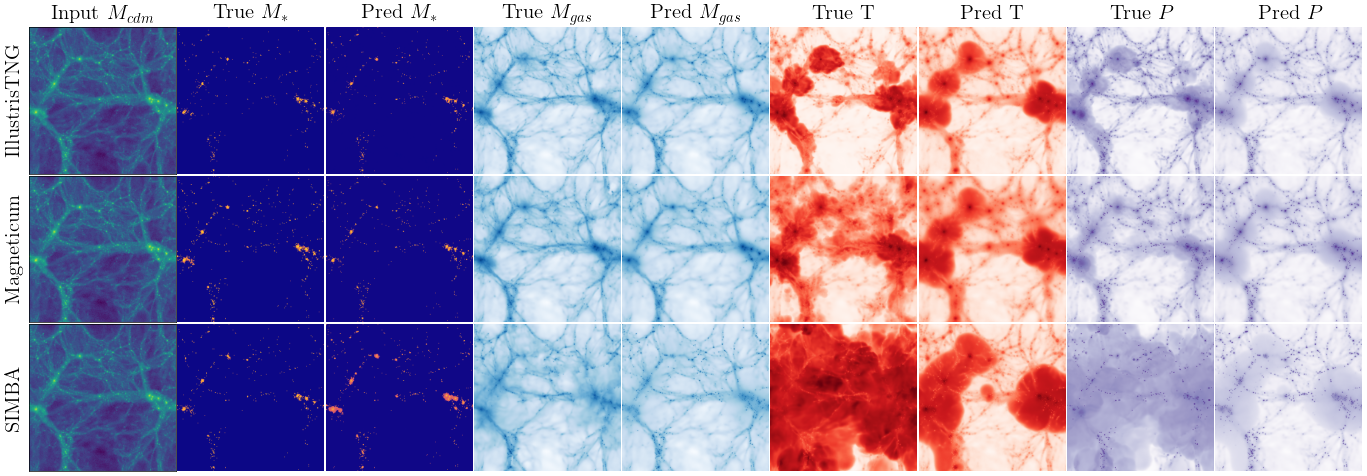

In [4]:
# Create figure with 2x9 grid of tightly tiled imshows
fig, axes = plt.subplots(3, 9, figsize=(17.2, 5.79))
fig.subplots_adjust(wspace=0.00, hspace=0.00)

# Dataset and channel configuration
dataset_names = ['IllustrisTNG', 'Magneticum', 'SIMBA']

channels = output['channels']
tot_mass_all = output['tot_mass_all']
params_list_all = output['params_list_all']

for row in range(3):
    sample_idx = row * 5
    
    # Column 0: Input DM map
    axes[row, 0].imshow(tot_mass_all[sample_idx], cmap='viridis')
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    if row == 0:
        axes[row, 0].set_title('Input $M_{cdm}$', fontsize=15)
    
    # Add dataset label on left
    # param_text = f"$\\Omega_m$={params_list_all[sample_idx][0]:.2f}, $\\sigma_8$={params_list_all[sample_idx][1]:.2f}"
    axes[row, 0].set_ylabel(f"{dataset_names[row]}", fontsize=15)
    
    # Columns 1-8: Channel pairs (true, pred)
    for ch_idx, (true_all, pred_all, pred_col, cmap, label) in enumerate(channels):
        col_true = 1 + ch_idx * 2
        col_pred = col_true + 1
        
        # True channel
        axes[row, col_true].imshow(true_all[sample_idx], cmap=cmap)
        # axes[row, col_true].set_xticks([])
        # axes[row, col_true].set_yticks([])
        axes[row, col_true].axis('off')
        if row == 0:
            axes[row, col_true].set_title(f'True {label}', fontsize=15)
        
        # Predicted channel
        axes[row, col_pred].imshow(pred_all[sample_idx][pred_col], cmap=cmap)
        # axes[row, col_pred].set_xticks([])
        # axes[row, col_pred].set_yticks([])
        axes[row, col_pred].axis('off')
        if row == 0:
            axes[row, col_pred].set_title(f'Pred {label}', fontsize=15)

# plt.tight_layout()
plt.subplots_adjust(wspace=0.01)
plt.show()

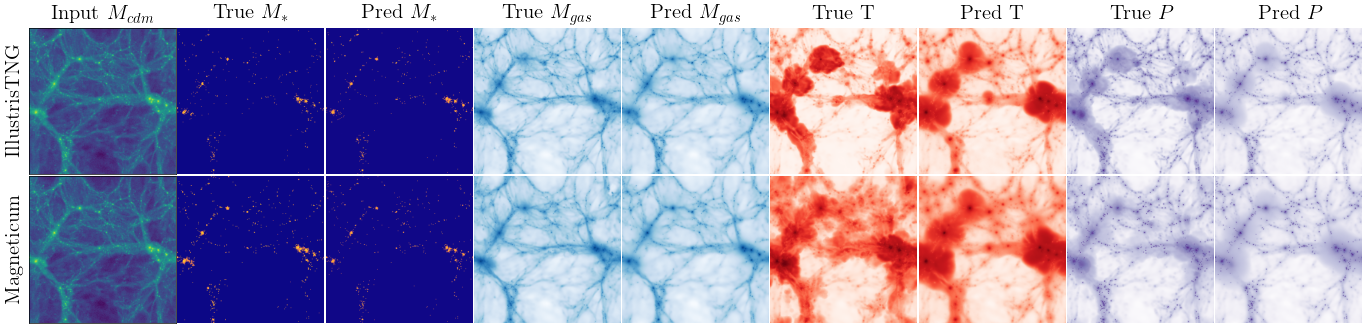

In [14]:
# Create figure with 2x9 grid of tightly tiled imshows
fig, axes = plt.subplots(2, 9, figsize=(17.2, 3.86))
fig.subplots_adjust(wspace=0.00, hspace=0.00)

# Dataset and channel configuration
dataset_names = ['IllustrisTNG', 'Magneticum', 'SIMBA']

channels = output['channels']
tot_mass_all = output['tot_mass_all']
params_list_all = output['params_list_all']

for row in range(2):
    sample_idx = row * 5
    
    # Column 0: Input DM map
    axes[row, 0].imshow(tot_mass_all[sample_idx], cmap='viridis')
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    if row == 0:
        axes[row, 0].set_title('Input $M_{cdm}$', fontsize=15)
    
    # Add dataset label on left
    # param_text = f"$\\Omega_m$={params_list_all[sample_idx][0]:.2f}, $\\sigma_8$={params_list_all[sample_idx][1]:.2f}"
    axes[row, 0].set_ylabel(f"{dataset_names[row]}", fontsize=15)
    
    # Columns 1-8: Channel pairs (true, pred)
    for ch_idx, (true_all, pred_all, pred_col, cmap, label) in enumerate(channels):
        col_true = 1 + ch_idx * 2
        col_pred = col_true + 1
        
        # True channel
        axes[row, col_true].imshow(true_all[sample_idx], cmap=cmap)
        # axes[row, col_true].set_xticks([])
        # axes[row, col_true].set_yticks([])
        axes[row, col_true].axis('off')
        if row == 0:
            axes[row, col_true].set_title(f'True {label}', fontsize=15)
        
        # Predicted channel
        axes[row, col_pred].imshow(pred_all[sample_idx][pred_col], cmap=cmap)
        # axes[row, col_pred].set_xticks([])
        # axes[row, col_pred].set_yticks([])
        axes[row, col_pred].axis('off')
        if row == 0:
            axes[row, col_pred].set_title(f'Pred {label}', fontsize=15)

# plt.tight_layout()
plt.subplots_adjust(wspace=0.01)
plt.savefig('grid1.pdf')
plt.show()

/tmp/ipykernel_3858140/1905429210.py:49: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 32)


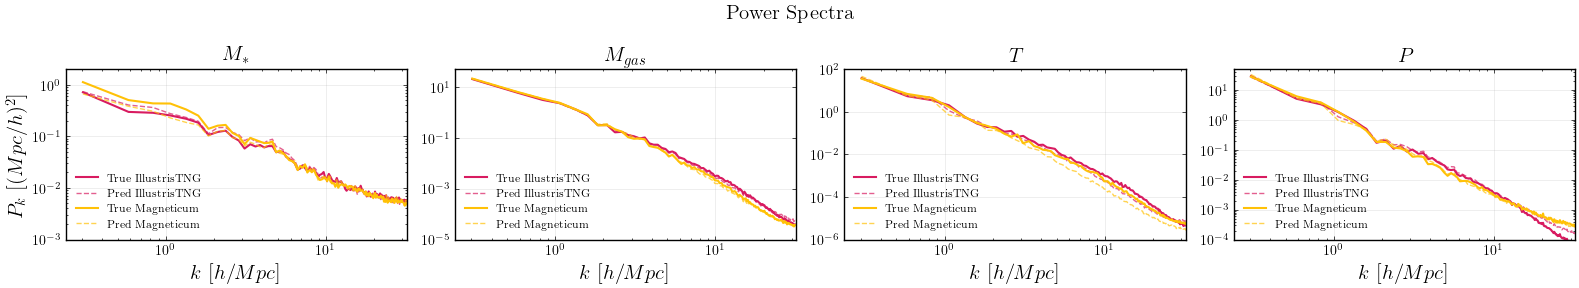

In [12]:
# ====================================================
# POWER SPECTRA FOR ALL THREE SIMULATIONS (OVERLAID)
# ====================================================

# Create figure with 1x4 subplots for power spectra
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

# Extract power spectra data from output dictionary
pk_results_all_channels = [
    output['power_spectra']['star'], 
    output['power_spectra']['gas'], 
    output['power_spectra']['T'], 
    output['power_spectra']['P']
]
pk_labels = ['$M_*$', '$M_{gas}$', '$T$', '$P$']
pk_colors = ['plasma', 'Blues', 'Reds', 'Purples']
simulation_names = ['IllustrisTNG', 'Magneticum', 'SIMBA']
sim_colors = ['#D81B60', '#FFC107', '#8F38BB']  # Different colors for each simulation
ranges = [(1e-3,2),(1e-5,50),(1e-6,100),(1e-4,50)]

# Plot for each channel
for ch_idx, (pk_res, label, cmap, r) in enumerate(zip(pk_results_all_channels, pk_labels, pk_colors, ranges)):
    ax = axes[ch_idx]
    
    # Plot each simulation
    for sim_idx in range(2):  # 3 simulations
        sample_idx = sim_idx * 5  # Each simulation has 5 samples
        sim_color = sim_colors[sim_idx]
        sim_name = simulation_names[sim_idx]
        
        k = pk_res[sample_idx]['k']
        pk_true = pk_res[sample_idx]['pk_true']
        valid = k > 0
        
        # True power spectrum for this simulation
        line_true, = ax.loglog(k[valid], pk_true[valid], '-', color=sim_color, lw=1.5, 
                              label=f'True {sim_name}')
        
        # Prediction (just one example from the 5 noise realisations)
        pk_pred = pk_res[sample_idx]['pk_pred']  # Use first noise realisation as example
        line_pred, = ax.loglog(k[valid], pk_pred[valid], '--', color=sim_color, alpha=0.7, lw=1, 
                              label=f'Pred {sim_name}')
    
    # Formatting
    ax.set_title(label, fontsize=15)
    ax.set_xlabel('$k$ [$h/Mpc$]', fontsize=15)
    if ch_idx==0:
        ax.set_ylabel('$P_k$ [$(Mpc/h)^2$]', fontsize=15)
    ax.set_xlim(0, 32)
    ax.set_ylim(r[0],r[1])
    ax.grid(alpha=0.3)
    ax.legend(loc='lower left', fontsize=8)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1)

# Overall title and layout
fig.suptitle("Power Spectra", fontsize=15, weight='bold')
plt.tight_layout()
plt.savefig('grid2.pdf')
plt.show()

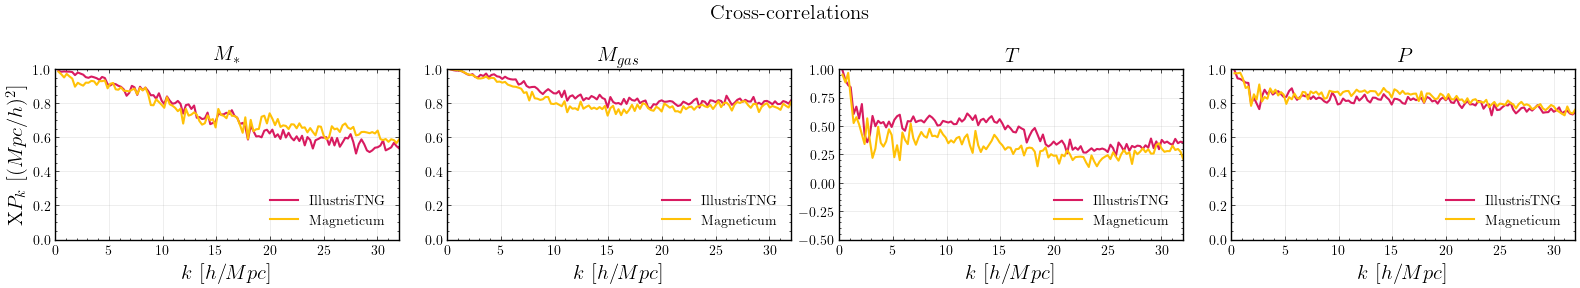

In [13]:
# ====================================================
# CROSS-CORRELATIONS FOR ALL THREE SIMULATIONS
# ====================================================

# Create figure with 1x4 subplots for correlations
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

# Extract correlation data from output dictionary
corr_results = [
    output['correlations']['star'], 
    output['correlations']['gas'], 
    output['correlations']['T'], 
    output['correlations']['P']
]
pk_labels = ['$M_*$', '$M_{gas}$', '$T$', '$P$']
pk_colors = ['plasma', 'Blues', 'Reds', 'Purples']
simulation_names = ['IllustrisTNG', 'Magneticum', 'SIMBA']
sim_colors = ['#D81B60', '#FFC107', '#8F38BB']  # Different colors for each simulation
# Plot for each channel
for ch_idx, (corr_res, label, cmap) in enumerate(zip(corr_results, pk_labels, pk_colors)):
    ax = axes[ch_idx]
    
    # Plot each simulation
    for sim_idx in range(2):  # 3 simulations
        sample_idx = sim_idx * 5  # Each simulation has 5 samples
        sim_color = sim_colors[sim_idx]
        sim_name = simulation_names[sim_idx]
        
        # Use first sample from each simulation as example
        r = corr_res[sample_idx]['r']
        xi = corr_res[sample_idx]['xi']
        
        line, = ax.plot(r, xi, '-', color=sim_color, lw=1.5, label=sim_name)
    
    # Formatting
    ax.set_title(label, fontsize=15)
    ax.set_xlabel('$k$ [$h/Mpc$]', fontsize=15)
    if ch_idx==0:
        ax.set_ylabel('$\\mathrm{X}P_k$ [$(Mpc/h)^2$]', fontsize=15)
    ax.set_xlim(0, 32)
    if ch_idx==2:
        ax.set_ylim(-0.5, 1)
    else:
        ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right', fontsize=10)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1)

# Overall title and layout
fig.suptitle("Cross-correlations ", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('grid3.pdf')
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
from scipy.fft import fft2, ifft2, fftshift

# =========================================================
# Model loading + single-sample inference
# =========================================================
def load_model(checkpoint_path, device=None):
    """Load trained flow matching model from checkpoint"""
    from module import FlowMatchingModel
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = FlowMatchingModel.load_from_checkpoint(checkpoint_path, map_location=device)
    model.to(device)
    model.eval()
    return model, device

def get_main_color(cmap_name, value=0.8):
    return plt.get_cmap(cmap_name)(value)

# =========================================================
# Main plotting for 5 samples with all 5 channels + power spectra
# =========================================================
def analyze_and_plot_five_samples(checkpoint_path,
                                  cdm_mass_path_lh, star_maps_path_lh, gas_maps_path_lh, T_maps_path_lh, P_maps_path_lh, params_path_lh,
                                  cdm_mass_path_mag, star_maps_path_mag, gas_maps_path_mag, T_maps_path_mag, P_maps_path_mag, params_path_mag,
                                  num_steps=50):
    model, device = load_model(checkpoint_path)

    # Load both datasets
    # LH dataset (for first row)
    cdm_mass_maps_lh = np.load(cdm_mass_path_lh)
    star_maps_lh = np.load(star_maps_path_lh)
    gas_maps_lh = np.load(gas_maps_path_lh)
    T_maps_lh = np.load(T_maps_path_lh)
    P_maps_lh = np.load(P_maps_path_lh)
    params_lh = np.loadtxt(params_path_lh)
    
    # Magneticum dataset (for second row)
    cdm_mass_maps_mag = np.load(cdm_mass_path_mag)
    star_maps_mag = np.load(star_maps_path_mag)
    gas_maps_mag = np.load(gas_maps_path_mag)
    T_maps_mag = np.load(T_maps_path_mag)
    P_maps_mag = np.load(P_maps_path_mag)
    params_mag = np.loadtxt(params_path_mag)

    # Stats for normalization (use LH dataset for consistency)
    tot = np.log1p(cdm_mass_maps_lh)
    tot_mean, tot_std = tot.mean(), tot.std()
    data_stats = {'tot_mean': tot_mean, 'tot_std': tot_std}

    # Select indices from each dataset
    # idx_lh = random.choice(range(len(cdm_mass_maps_lh)))
    # idx_mag = random.choice(range(len(cdm_mass_maps_mag)))
    idx_lh, idx_mag = 0, 0  # For reproducible results

    preds_all, stars_true_all, gas_true_all, T_true_all, P_true_all, tot_mass_all, params_list_all = [], [], [], [], [], [], []
    star_pk_results, gas_pk_results, T_pk_results, P_pk_results = [], [], [], []
    star_corr_results, gas_corr_results, T_corr_results, P_corr_results = [], [], [], []
    dataset_labels = []

    # Process both samples
    datasets = [
        (idx_lh, cdm_mass_maps_lh, star_maps_lh, gas_maps_lh, T_maps_lh, P_maps_lh, params_lh, "LH"),
        (idx_mag, cdm_mass_maps_mag, star_maps_mag, gas_maps_mag, T_maps_mag, P_maps_mag, params_mag, "Magneticum")
    ]

    for idx, cdm_mass_maps, star_maps, gas_maps, T_maps, P_maps, params, dataset_name in datasets:
        # Clean condition map
        sample_tot = np.log1p(cdm_mass_maps[idx])
        sample_tot_norm = (sample_tot - data_stats['tot_mean']) / data_stats['tot_std']

        # Noisy x0 maps
        noisy_tot_list = [
            sample_tot_norm + np.random.normal(loc=0, scale=0.2, size=(256, 256))
            for _ in range(5)
        ]

        # Load truth maps (norm by their own mean/std as before)
        star_map = np.log1p(star_maps[idx])
        gas_map = np.log1p(gas_maps[idx])
        T_map = np.log1p(T_maps[idx])
        P_map = np.log1p(P_maps[idx])
        
        star_map_norm = (star_map - star_map.mean()) / star_map.std()
        gas_map_norm = (gas_map - gas_map.mean()) / gas_map.std()
        T_map_norm = (T_map - T_map.mean()) / T_map.std()
        P_map_norm = (P_map - P_map.mean()) / P_map.std()
        
        astro_params = params[idx//15, :2]

        # Stack all five channels: star, gas, temperature, HI, P
        truth_maps = np.stack([star_map_norm, gas_map_norm, T_map_norm, P_map_norm], axis=0)
        resnet_input_tensor = torch.tensor(truth_maps, dtype=torch.float32).unsqueeze(0).to(device)
        
        # Repeat for each noisy version
        for noisy_tot in noisy_tot_list:
            cdm_mass_tensor = torch.tensor(noisy_tot, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            cond_tensor = torch.tensor(sample_tot_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            params_tensor = torch.tensor(astro_params, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model.sample(
                    cdm_mass=cdm_mass_tensor,
                    astro_params=params_tensor,
                    cdm_mass_condition=cond_tensor,
                    resnet_input=resnet_input_tensor,
                    num_steps=num_steps,
                    method='euler'
                ).cpu().numpy()[0]

            preds_all.append(pred)
            stars_true_all.append(star_map_norm)
            gas_true_all.append(gas_map_norm)
            T_true_all.append(T_map_norm)
            P_true_all.append(P_map_norm)
            tot_mass_all.append(noisy_tot)
            params_list_all.append(astro_params)
            dataset_labels.append(dataset_name)

            # Power spectrum + correlation for all five channels
            # Stars
            k_star_pred, pk_star_pred = get_pk(pred[0])
            k_star_true, pk_star_true = get_pk(star_map_norm)
            star_pk_results.append({
                'k': k_star_pred,
                'pk_pred': pk_star_pred,
                'pk_true': pk_star_true,
                'error': np.abs(pk_star_pred - pk_star_true) / (pk_star_true + 1e-10)
            })

            # Gas
            k_gas_pred, pk_gas_pred = get_pk(pred[1])
            k_gas_true, pk_gas_true = get_pk(gas_map_norm)
            gas_pk_results.append({
                'k': k_gas_pred,
                'pk_pred': pk_gas_pred,
                'pk_true': pk_gas_true,
                'error': np.abs(pk_gas_pred - pk_gas_true) / (pk_gas_true + 1e-10)
            })

            # Temperature
            k_T_pred, pk_T_pred = get_pk(pred[2])
            k_T_true, pk_T_true = get_pk(T_map_norm)
            T_pk_results.append({
                'k': k_T_pred,
                'pk_pred': pk_T_pred,
                'pk_true': pk_T_true,
                'error': np.abs(pk_T_pred - pk_T_true) / (pk_T_true + 1e-10)
            })

            # P
            k_P_pred, pk_P_pred = get_pk(pred[3])
            k_P_true, pk_P_true = get_pk(P_map_norm)
            P_pk_results.append({
                'k': k_P_pred,
                'pk_pred': pk_P_pred,
                'pk_true': pk_P_true,
                'error': np.abs(pk_P_pred - pk_P_true) / (pk_P_true + 1e-10)
            })

            # Correlations
            r_star, xi_star = get_xcorr(pred[0], star_map_norm)
            r_gas, xi_gas = get_xcorr(pred[1], gas_map_norm)
            r_T, xi_T = get_xcorr(pred[2], T_map_norm)
            r_P, xi_P = get_xcorr(pred[3], P_map_norm)
            
            star_corr_results.append({'r': r_star, 'xi': xi_star})
            gas_corr_results.append({'r': r_gas, 'xi': xi_gas})
            T_corr_results.append({'r': r_T, 'xi': xi_T})
            P_corr_results.append({'r': r_P, 'xi': xi_P})


    
    # --- Create figure with 3 stacked subfigures ---
    fig = plt.figure(figsize=(22, 10))
    subfigs = fig.subfigures(3, 1, height_ratios=[3, 1.2, 1.2])
    
    # ====================================================
    # 1) MAPS SECTION
    # ====================================================
    sf_maps = subfigs[0]
    gs_maps = sf_maps.add_gridspec(2, 1 + 4*2, wspace=0.02, hspace=0.02)  
    # 2 datasets (rows), 1 DM col + 4 channels × (true, pred)
    
    dataset_names = ['IllustrisTNG', 'Magneticum']
    channels = [
        (stars_true_all, preds_all, 0, 'plasma', '$M_*$'),
        (gas_true_all, preds_all, 1, 'Blues', '$M_{gas}$'),
        (T_true_all, preds_all, 2, 'Reds', 'T'),
        (P_true_all, preds_all, 3, 'Purples', '$P$')
    ]
    
    for row in range(2):
        sample_idx = row * 5
    
        # Input DM map
        ax_dm = sf_maps.add_subplot(gs_maps[row, 0])
        ax_dm.imshow(tot_mass_all[sample_idx], cmap='viridis')
        if row == 0: ax_dm.set_title('Input $M_{cdm}$', fontsize=12)
        ax_dm.set_xticks([]); ax_dm.set_yticks([])
        param_text = f"$\\Omega_m$={params_list_all[sample_idx][0]:.2f}, $\\sigma_8$={params_list_all[sample_idx][1]:.2f}"
        ax_dm.set_ylabel(f"{dataset_names[row]}\n{param_text}", fontsize=10)
    
        # Channels (true, pred)
        for ch_idx, (true_all, pred_all, pred_col, cmap, label) in enumerate(channels):
            col_start = 1 + ch_idx * 2
            # True
            ax_true = sf_maps.add_subplot(gs_maps[row, col_start])
            ax_true.imshow(true_all[sample_idx], cmap=cmap)
            if row == 0: ax_true.set_title(f'True {label}', fontsize=12)
            ax_true.set_xticks([]); ax_true.set_yticks([])
            # Pred
            ax_pred = sf_maps.add_subplot(gs_maps[row, col_start + 1])
            ax_pred.imshow(pred_all[sample_idx][pred_col], cmap=cmap)
            if row == 0: ax_pred.set_title(f'Pred {label}', fontsize=12)
            ax_pred.set_xticks([]); ax_pred.set_yticks([])
    
    # ====================================================
    # 2) POWER SPECTRA SECTION
    # ====================================================
    sf_pk = subfigs[1]
    ax_pk_list = sf_pk.subplots(1, 4, sharex=False, sharey=False)
    pk_results_all_channels = [star_pk_results, gas_pk_results, T_pk_results, P_pk_results]
    pk_labels = ['$M_*$', '$M_{gas}$', '$T$', '$P$']
    pk_colors = ['plasma', 'Blues', 'Reds', 'Purples']
    
    pk_legend_handles = []
    last_sample_idx = 0  # pick second dataset example
    
    for ax, pk_res, label, cmap in zip(ax_pk_list, pk_results_all_channels, pk_labels, pk_colors):
        k = pk_res[last_sample_idx]['k']
        pk_true = pk_res[last_sample_idx]['pk_true']
        valid = k > 0
        c = get_main_color(cmap, 0.8)
    
        # True
        line_true, = ax.loglog(k[valid], pk_true[valid], '-', color=c, lw=1.5, label='True')
        # Predictions (5 noise realisations)
        line_pred = None
        for j in range(5):
            pk_pred = pk_res[last_sample_idx + j]['pk_pred']
            line_pred, = ax.loglog(k[valid], pk_pred[valid], '--', color=c, alpha=0.5, lw=1, label='$\\sigma=0.2$'if j==0 else None)
    
        if label == '$M_*$':
            pk_legend_handles.extend([line_true, line_pred])
    
        ax.set_title(label, fontsize=11)
        ax.set_xlabel('k', fontsize=9)
        ax.set_xlim(0, 32)
        ax.grid(alpha=0.3)
        ax.legend(loc='lower left')
    sf_pk.suptitle("Power Spectra", fontsize=13, weight='bold')
    
    # ====================================================
    # 3) CROSS-CORRELATIONS SECTION
    # ====================================================
    sf_corr = subfigs[2]
    ax_corr_list = sf_corr.subplots(1, 4, sharex=False, sharey=False)
    corr_results = [star_corr_results, gas_corr_results, T_corr_results, P_corr_results]
    
    corr_legend_handles = []
    for ax, corr_res, label, cmap in zip(ax_corr_list, corr_results, pk_labels, pk_colors):
        c = get_main_color(cmap, 0.8)
        # TNG
        r_lh = corr_res[0]['r']
        xi_lh = corr_res[0]['xi']
        line_tng, = ax.plot(r_lh, xi_lh, '-', color=c, lw=1.5, label='TNG')
        # Mag
        r_mag = corr_res[5]['r']
        xi_mag = corr_res[5]['xi']
        line_mag, = ax.plot(r_mag, xi_mag, '--', color=c, lw=1.5, label='Mag')
    
        if label == '$M_*$':
            corr_legend_handles.extend([line_tng, line_mag])
    
        ax.set_title(label, fontsize=11)
        ax.set_xlabel('k', fontsize=9)
        ax.set_xlim(0, 32)
        ax.set_ylim(0,1)
        ax.grid(alpha=0.3)
        ax.legend(loc='lower left')
    
    sf_corr.suptitle("Cross-correlations", fontsize=13, weight='bold')
    plt.subplots_adjust(hspace=0.35)  # adds space between all rows
    # ====================================================
    fig.tight_layout(pad=0.5)
    fig.subplots_adjust(top=0.75)
    plt.savefig('optimized_layout.png', dpi=200, bbox_inches='tight')
    plt.show()



# Usage
analyze_and_plot_five_samples(
    checkpoint_path='/n/netscratch/iaifi_lab/Lab/msliu/FM_4channel/lightning_logs/4channel/checkpoints/best-model-epoch=165-val_loss=0.025589.ckpt',
    # LH dataset paths
    cdm_mass_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_Mcdm_IllustrisTNG_CV_z=0.00.npy',
    star_maps_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_Mstar_IllustrisTNG_CV_z=0.00.npy',
    gas_maps_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_Mgas_IllustrisTNG_CV_z=0.00.npy',
    T_maps_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_T_IllustrisTNG_CV_z=0.00.npy',
    P_maps_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_P_IllustrisTNG_CV_z=0.00.npy',
    params_path_lh='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/params_CV_IllustrisTNG.txt',
    # Magneticum dataset paths
    cdm_mass_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/Maps_Mcdm_Magneticum_CV_z=0.00.npy',
    star_maps_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/Maps_Mstar_Magneticum_CV_z=0.00.npy',
    gas_maps_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/Maps_Mgas_Magneticum_CV_z=0.00.npy',
    T_maps_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/Maps_T_Magneticum_CV_z=0.00.npy',
    P_maps_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/Maps_P_Magneticum_CV_z=0.00.npy',
    params_path_mag='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/Magneticum/params_CV_Magneticum.txt',
    num_steps=100
)


Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time t

/tmp/ipykernel_3858140/3167318108.py:252: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 32)
/tmp/ipykernel_3858140/3167318108.py:289: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.5)


KeyboardInterrupt: 